We are building a Sequential Workflow using LangGraph and Google Gemini. Our objective is to create a Sequential System for  Telecom SIM Activation & Fraud Verification Workflow

In [1]:
!pip install langgraph langchain langchain-google-genai google-generativeai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 855.0 kB/s eta 0:00:00


In [2]:
#Installing the required dependencies
from langgraph.graph import StateGraph, START, END #START and END are dummy nodes in LangGraph
from typing import TypedDict #this is a special type of Dict where we specify the datatype also
from langchain_google_genai import ChatGoogleGenerativeAI #for getting a response from the LLM
from langchain_core.tools import tool
from IPython.display import Image #visualize the workflow created using LangGraph

In [ ]:
#Configuring the Gemini API
import os
os.environ["GOOGLE_API_KEY"]="placeholder"

In [4]:
#Initializing the Gemini LLM
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [13]:
from typing import TypedDict

class TelecomState(TypedDict):

    # Inputs from User
    aadhaar_number: str
    pan_number: str
    customer_location: str
    previous_sim_requests: int

    # Step 1 Output (KYC Tool)
    kyc_status: str

    # Step 2 Output (Gemini Fraud Analysis)
    fraud_risk: str

    # Step 3 Output (Final Decision)
    final_decision: str

With respect to Tools, we should always have the following 3 things defined in a Tool

- Name of the Tool
- Description of the Tool
- Input schema of the Tool

In [14]:
#Creating a Tool which does kyc verification

@tool
def kyc_verification_tool(aadhaar_number: str, pan_number: str) -> str:
    """
    This tool verifies customer KYC details
    using Aadhaar and PAN information.
    """

    # Aadhaar Validation
    if len(aadhaar_number) != 12 or not aadhaar_number.isdigit():
        return "INVALID_DOCUMENT"

    # PAN Validation
    if len(pan_number) != 10:
        return "INVALID_DOCUMENT"

    # Example Pending Verification Condition
    if aadhaar_number.startswith("0000"):
        return "PENDING_VERIFICATION"

    # If all validations pass
    return "VERIFIED"

In [15]:
#Creating a Node KYC_Verification_Node
def KYC_Verification_Node(state: TelecomState) -> TelecomState:

    result = kyc_verification_tool.invoke({
        "aadhaar_number": state['aadhaar_number'],
        "pan_number": state['pan_number']
    })

    # Store tool output in workflow state
    state['kyc_status'] = result

    return state

In [16]:
# Creating a Node for Fraud Detection using Gemini

def fraud_detection_node(state: TelecomState) -> TelecomState:

    prompt = f"""
    Analyze this telecom SIM activation request.

    Customer Location: {state['customer_location']}
    Previous SIM Requests: {state['previous_sim_requests']}
    KYC Status: {state['kyc_status']}

    Classify the fraud risk strictly as one of:
    LOW_RISK
    MEDIUM_RISK
    HIGH_RISK
    """

    response = llm.invoke(prompt)

    # Store Gemini output in workflow state
    state['fraud_risk'] = response.content.strip()

    return state

In [17]:
# Creating Final Activation Decision Node

def activation_decision_node(state: TelecomState) -> TelecomState:

    # Decision based on fraud risk
    if state['fraud_risk'] == "LOW_RISK":
        state['final_decision'] = "SIM_ACTIVATED"

    elif state['fraud_risk'] == "MEDIUM_RISK":
        state['final_decision'] = "MANUAL_REVIEW"

    elif state['fraud_risk'] == "HIGH_RISK":
        state['final_decision'] = "REJECT_APPLICATION"

    else:
        state['final_decision'] = "UNKNOWN_STATUS"

    return state

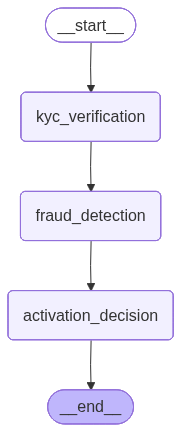

In [21]:
# Compiling the Telecom Workflow

from langgraph.graph import StateGraph, END

graph = StateGraph(TelecomState)

# Adding Nodes
graph.add_node("kyc_verification", KYC_Verification_Node)
graph.add_node("fraud_detection", fraud_detection_node)
graph.add_node("activation_decision", activation_decision_node)

# Entry Point
graph.set_entry_point("kyc_verification")

# Connecting Nodes
graph.add_edge("kyc_verification", "fraud_detection")
graph.add_edge("fraud_detection", "activation_decision")
graph.add_edge("activation_decision", END)

# Compile Workflow
workflow = graph.compile()
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))


In [22]:
initial_state:TelecomState={

    "aadhaar_number": "123456789012",
    "pan_number": "ABCDE1234F",
    "customer_location": "Bangalore",
    "previous_sim_requests": 2

}

print(workflow.invoke(initial_state))

{'aadhaar_number': '123456789012', 'pan_number': 'ABCDE1234F', 'customer_location': 'Bangalore', 'previous_sim_requests': 2, 'kyc_status': 'VERIFIED', 'fraud_risk': 'Let\'s break down the factors:\n\n1.  **Customer Location: Bangalore**\n    *   **Fraud Impact:** Neutral. A major city, but doesn\'t inherently increase or decrease fraud risk on its own.\n\n2.  **Previous SIM Requests: 2** (This implies the current request would be for a *third* SIM under the same identity).\n    *   **Fraud Impact:** **HIGH RISK.** This is a significant red flag. While some individuals might have two SIMs (e.g., personal and work), a third SIM for the same individual is highly unusual and a strong indicator of potential SIM farming, misuse of identity, or other fraudulent activity (e.g., creating multiple accounts for scams, OTP bypass, reselling SIMs). Most legitimate users rarely need more than two SIMs from the same operator.\n\n3.  **KYC Status: VERIFIED**\n    *   **Fraud Impact:** **LOW RISK.** Th